In [1]:
import pandas as pd
chess = pd.read_csv('chess_games.csv')

In [2]:
chess.head()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


In [3]:
chess.dtypes

id                 object
rated                bool
created_at        float64
last_move_at      float64
turns               int64
victory_status     object
winner             object
increment_code     object
white_id           object
white_rating        int64
black_id           object
black_rating        int64
moves              object
opening_eco        object
opening_name       object
opening_ply         int64
dtype: object

### Task 1: Inspect Before Plotting


In [4]:
chess.describe()

,created_at,last_move_at,turns,white_rating,black_rating,opening_ply
count,2.005800e+04,2.005800e+04,20058.000000,20058.000000,20058.000000,20058.000000
mean,1.483617e+12,1.483618e+12,60.465999,1596.631868,1588.831987,4.816981
std,2.850151e+10,2.850140e+10,33.570585,291.253376,291.036126,2.797152
min,1.376772e+12,1.376772e+12,1.000000,784.000000,789.000000,1.000000
25%,1.477548e+12,1.477548e+12,37.000000,1398.000000,1391.000000,3.000000
50%,1.496010e+12,1.496010e+12,55.000000,1567.000000,1562.000000,4.000000
75%,1.503170e+12,1.503170e+12,79.000000,1793.000000,1784.000000,6.000000
max,1.504493e+12,1.504494e+12,349.000000,2700.000000,2723.000000,28.000000


3. numerical: white rating, black rating, turns; categorical: opening name, victory status, rated, winner

Discussion:
Values that can't be grouped into specific categories because they are unique to each row. Are they considered categories?

### Task 2: A Column of Categories


1. data type is an object.
2. bar chart

Discussion: because you can't really tell the exact quantities represented by the portions. 

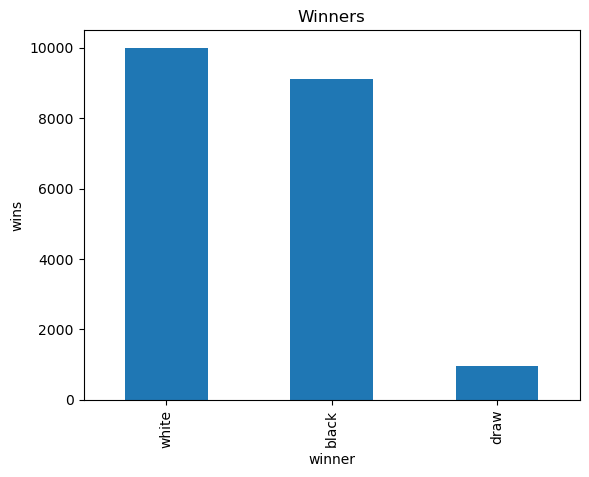

In [5]:
winner_counts = chess["winner"].value_counts().plot(kind ="bar", title="Winners", ylabel="wins")

#Task 3: A Numerical Distribution

<Axes: ylabel='Frequency'>

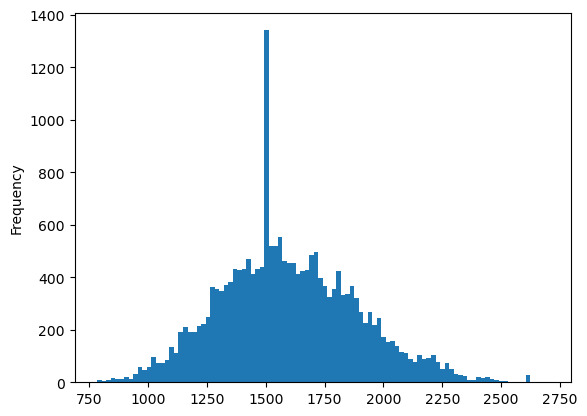

In [6]:
chess['white_rating'].plot(kind='hist', bins=100)

1. Discrete data
2. When we have bin at 5, it hides what the majority of the players sit at.

#Task 4: Two Numerical Columns Together

<Axes: xlabel='white_rating', ylabel='black_rating'>

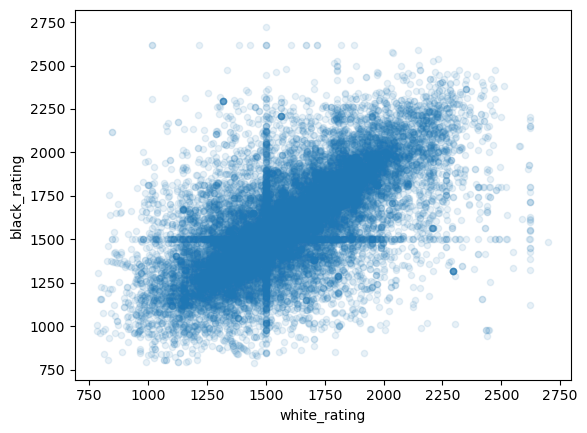

In [7]:
chess[['white_rating', 'black_rating']].plot(kind='scatter', x='white_rating', y='black_rating', alpha=0.1)

1. The pattern slopes up.
2. Opponents ratings are evenly matched

#Task 5: Correlation Is Not Causation

1. The pattern is if the white_rating goes up the black_rating follows.
2. There is skill based match making. They will not put someone with a 2250 rating against someone with 750 rating in a tournament.

### Task 6

1. Turn is discrete, you can't have half a turn.
2. Makes more sense as a histogram, too many values to group into bar chart

<Axes: xlabel='count', ylabel='Frequency'>

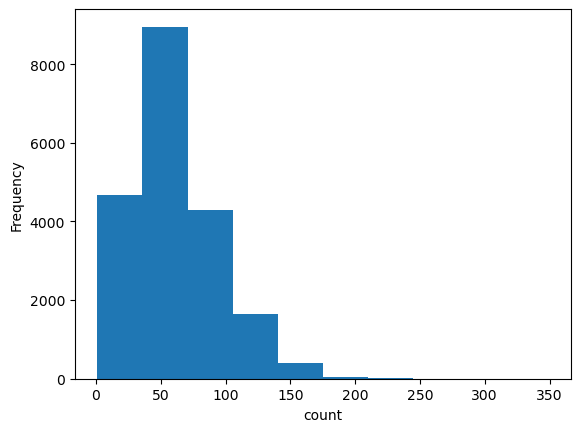

In [ ]:
chess_turns = chess["turns"].value_counts()

'''
chess_turns.plot(
    kind="bar",
    ylabel="count"
)
'''

chess["turns"].plot(
    kind="hist",
    xlabel="count"
)

### Task 7

In [ ]:
chess.groupby("victory_status")["turns"].mean().sort_values(ascending=False)

# Draw takes the longest, no it's not surprising

victory_status
draw         83.781457
outoftime    72.742857
mate         65.415020
resign       53.912533
Name: turns, dtype: float64

### Task 8

<Axes: xlabel='start_date'>

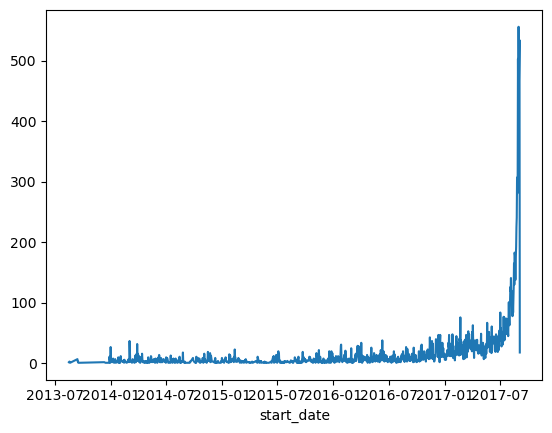

In [ ]:
chess["start_date"] = pd.to_datetime(
    chess["created_at"], unit="ms"
)

daily = chess["start_date"].dt.date.value_counts().sort_index()

daily.plot(
    kind="line",
)

### Task 9

<Axes: title={'center': 'Opening Moves'}, xlabel='Number of Games', ylabel='opening_name'>

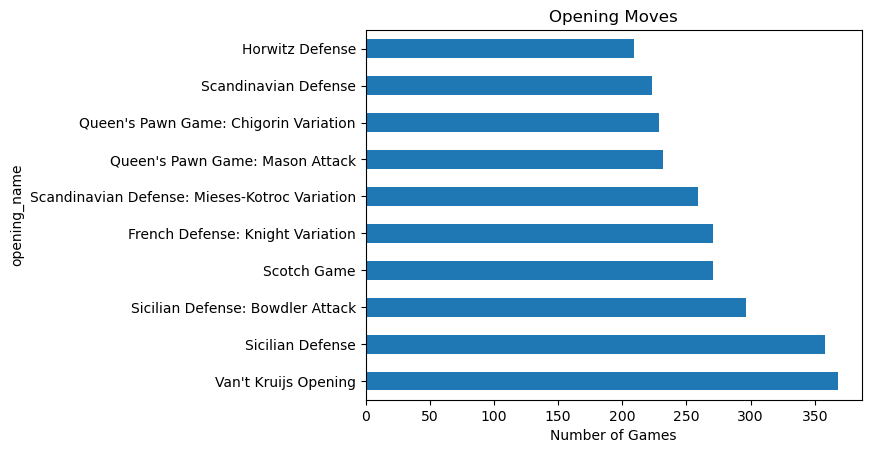

In [ ]:
top_openings = chess["opening_name"].value_counts().head(10)

top_openings.plot(
    kind="barh",
    title="Opening Moves",
    xlabel="Number of Games"
)

# The names are too long, they make the formatting weird